# Gradient Decent (Gradientenabstieg) — Werbeausgaben vs. Verkäufe

**Ziel:** Bei der Mietpreisvorhersage haben wir `w` und `b` von Hand geraten. Hier lassen wir den Computer die beste Gerade `y = w * x + b` selbst finden — mit dem **Gradient Decent** (Gradient Descent), dem grundlegenden Trainingsverfahren hinter den meisten ML-Modellen.

---

In [24]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

## 1. Daten erzeugen

Wir tragen 15 Werbekampagnen von Hand ein: Werbeausgaben (in Mio. $) und die dazugehörigen Verkäufe (in Einheiten).

In [23]:
# Manuell eingetragene Daten: Werbeausgaben (Mio. $) → Verkäufe (Einheiten)
x_spendings = np.array([ 4,  6,  9, 12, 15, 18, 21, 24, 27, 30, 33, 36, 39, 42, 46])
y_sales     = np.array([ 5,  8,  8, 12, 13, 14, 17, 17, 20, 20, 23, 23, 26, 27, 29])

## 2. Daten visualisieren

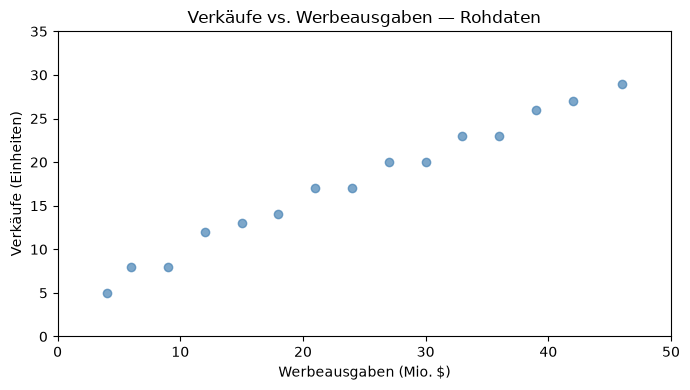

In [8]:
plt.figure(figsize=(7, 4))
plt.scatter(x_spendings, y_sales, color="steelblue", alpha=0.7)
plt.xlim(0, 50)
plt.ylim(0, 35)
plt.xlabel("Werbeausgaben (Mio. $)")
plt.ylabel("Verkäufe (Einheiten)")
plt.title("Verkäufe vs. Werbeausgaben — Rohdaten")
plt.tight_layout()
plt.show()

## 3. Verlustfunktion

Um zu messen, wie gut eine Gerade zu den Daten passt, brauchen wir eine **Verlustfunktion**. Wir verwenden den mittleren quadratischen Fehler (Mean Squared Error, MSE):

$$
l=\frac{1}{N}\sum_{i=1}^{N}\left(y_i-(wx_i+b)\right)^2
$$

Je kleiner der Verlust, desto besser die Gerade. Starten wir mit einer schlechten Anfangsvermutung `w=0, b=0` — eine flache Linie bei 0.

Anfangsverlust bei w=0.0, b=0.0: 356.27


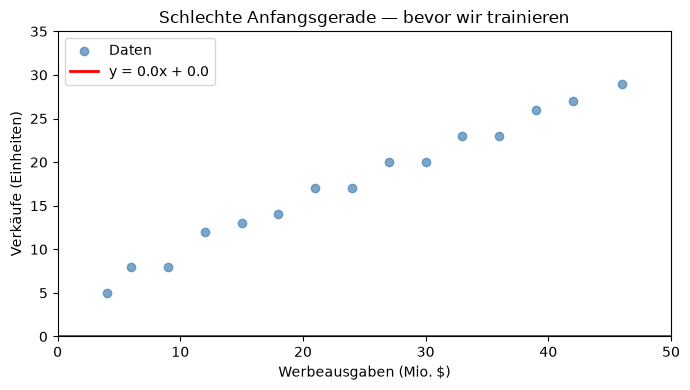

In [28]:
def loss(x_spendings, y_sales, w, b):
    prediction = w * x_spendings + b
    return np.mean((y_sales - prediction) ** 2)

w, b = 0.0, 0.0
print(f"Anfangsverlust bei w={w}, b={b}: {loss(x_spendings, y_sales, w, b):.2f}")

plt.figure(figsize=(7, 4))
plt.scatter(x_spendings, y_sales, color="steelblue", alpha=0.7, label="Daten")
x_line = np.linspace(0, 50, 50)
plt.plot(x_line, w * x_line + b, color="red", lw=2, label=f"y = {w:.1f}x + {b:.1f}")
plt.xlim(0, 50)
plt.ylim(0, 35)
plt.xlabel("Werbeausgaben (Mio. $)")
plt.ylabel("Verkäufe (Einheiten)")
plt.title("Schlechte Anfangsgerade — bevor wir trainieren")
plt.legend()
plt.tight_layout()
plt.show()

## 4. Gradienten berechnen

Der **Gradient** zeigt an, in welche Richtung `w` und `b` verändert werden müssen, um den Verlust zu vergrößern — wir gehen also in die *entgegengesetzte* Richtung, um ihn zu verkleinern. Das sind die partiellen Ableitungen des loss nach `w` und `b`:

$$
\frac{\partial l}{\partial w}
=
\frac{1}{N}
\sum_{i=1}^{N}
-2x_i\left(y_i-(wx_i+b)\right)
$$

$$
\frac{\partial l}{\partial b}
=
\frac{1}{N}
\sum_{i=1}^{N}
-2\left(y_i-(wx_i+b)\right)
$$

Ein Trainingsschritt aktualisiert `w` und `b` um einen kleinen Schritt (gesteuert von der **Lernrate** `alpha`) entgegen dem Gradienten.

In [50]:
def update_w_and_b(x_spendings, y_sales, w, b, alpha):

    N = len(x_spendings)

    dl_dw = (-2 / N) * np.sum(x_spendings * (y_sales - (w * x_spendings + b)))
    dl_db = (-2 / N) * np.sum(y_sales - (w * x_spendings + b))

      
    w = w - alpha * dl_dw
    b = b - alpha * dl_db
    return w, b


print("Ein einzelner Trainingsschritt von w=0, b=0 aus:")
w, b = update_w_and_b(x_spendings, y_sales, 0.0, 0.0, alpha=0.001)
print("w: ", w)
print("b: ", b)

Ein einzelner Trainingsschritt von w=0, b=0 aus:
w:  1.0273333333333332
b:  0.03493333333333333


## 5. Trainings-Schleife

Wir wiederholen den Update-Schritt viele tausend Male (**Epochen**). Bei jeder Epoche sollte der Verlust ein kleines Stück sinken.

In [41]:
def train(x_spendings, y_sales, w, b, alpha, epochs):
    verlauf = []
    for e in range(epochs):
        w, b = update_w_and_b(x_spendings, y_sales, w, b, alpha)
        aktueller_verlust = loss(x_spendings, y_sales, w, b)
        verlauf.append(aktueller_verlust)
        if e == 0 or (e < 3000 and e % 400 == 0) or e % 3000 == 0:
            print(f"Epoche {e:>5}: Verlust = {aktueller_verlust:.3f}, w = {w:.4f}, b = {b:.4f}")
    return w, b, verlauf

w, b, verlauf = train(x_spendings, y_sales, w=0.0, b=0.0, alpha=0.001, epochs=16000)

Epoche     0: Verlust = 93.489, w = 1.0273, b = 0.0349
Epoche   400: Verlust = 3.468, w = 0.6614, b = 0.7151
Epoche   800: Verlust = 2.631, w = 0.6429, b = 1.2930
Epoche  1200: Verlust = 2.045, w = 0.6273, b = 1.7761
Epoche  1600: Verlust = 1.636, w = 0.6143, b = 2.1800
Epoche  2000: Verlust = 1.349, w = 0.6035, b = 2.5178
Epoche  2400: Verlust = 1.149, w = 0.5944, b = 2.8001
Epoche  2800: Verlust = 1.010, w = 0.5868, b = 3.0362
Epoche  3000: Verlust = 0.956, w = 0.5835, b = 3.1393
Epoche  6000: Verlust = 0.703, w = 0.5573, b = 3.9527
Epoche  9000: Verlust = 0.686, w = 0.5505, b = 4.1651
Epoche 12000: Verlust = 0.685, w = 0.5487, b = 4.2205
Epoche 15000: Verlust = 0.685, w = 0.5482, b = 4.2350


## 6. Trainingsverlauf visualisieren

Der Verlust sollte mit jeder Epoche sinken und sich schließlich einem Minimum annähern.

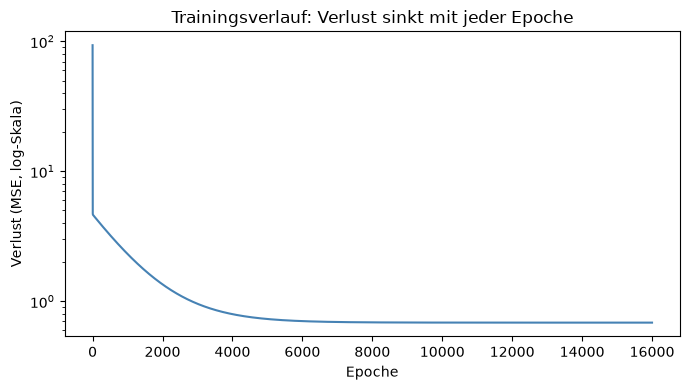

In [31]:
plt.figure(figsize=(7, 4))
plt.plot(verlauf, color="steelblue")
plt.yscale("log")
plt.xlabel("Epoche")
plt.ylabel("Verlust (MSE, log-Skala)")
plt.title("Trainingsverlauf: Verlust sinkt mit jeder Epoche")
plt.tight_layout()
plt.show()

## 7. Ergebnis: die trainierte Gerade

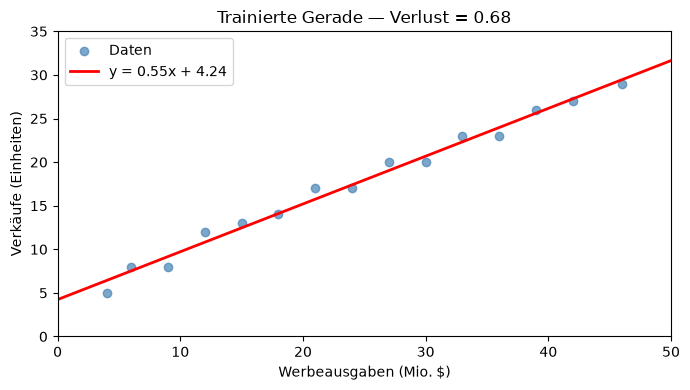

In [32]:
plt.figure(figsize=(7, 4))
plt.scatter(x_spendings, y_sales, color="steelblue", alpha=0.7, label="Daten")
x_line = np.linspace(0, 50, 50)
plt.plot(x_line, w * x_line + b, color="red", lw=2, label=f"y = {w:.2f}x + {b:.2f}")
plt.xlim(0, 50)
plt.ylim(0, 35)
plt.xlabel("Werbeausgaben (Mio. $)")
plt.ylabel("Verkäufe (Einheiten)")
plt.title(f"Trainierte Gerade — Verlust = {loss(x_spendings, y_sales, w, b):.2f}")
plt.legend()
plt.tight_layout()
plt.show()

## 7b. Die Gerade bei verschiedenen Epochen

Statt nur das Endergebnis zu zeigen, können wir die Gerade an mehreren Punkten während des Trainings festhalten und vergleichen, wie sie sich mit steigender Epochenzahl der Datenwolke annähert.

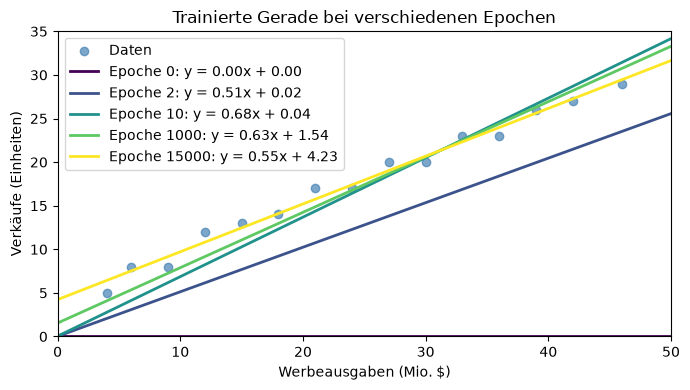

In [33]:
epochen_to_plot = [0, 2, 10, 1000, 15000]

w_schritt, b_schritt = 0.0, 0.0
schnappschuesse = {0: (w_schritt, b_schritt)}
for e in range(1, max(epochen_to_plot) + 1):
    w_schritt, b_schritt = update_w_and_b(x_spendings, y_sales, w_schritt, b_schritt, alpha=0.001)
    if e in epochen_to_plot:
        schnappschuesse[e] = (w_schritt, b_schritt)

plt.figure(figsize=(7, 4))
plt.scatter(x_spendings, y_sales, color="steelblue", alpha=0.7, label="Daten")
x_line = np.linspace(0, 50, 50)
farben = plt.cm.viridis(np.linspace(0, 1, len(epochen_to_plot)))
for epoche, farbe in zip(epochen_to_plot, farben):
    w_e, b_e = schnappschuesse[epoche]
    plt.plot(x_line, w_e * x_line + b_e, color=farbe, lw=2,
              label=f"Epoche {epoche}: y = {w_e:.2f}x + {b_e:.2f}")
plt.xlim(0, 50)
plt.ylim(0, 35)
plt.xlabel("Werbeausgaben (Mio. $)")
plt.ylabel("Verkäufe (Einheiten)")
plt.title("Trainierte Gerade bei verschiedenen Epochen")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Vorhersage für neue Werbeausgaben

In [34]:
def predict(x, w, b):
    return w * x + b

x_neu = 23.0
y_neu = predict(x_neu, w, b)
print(f"Werbeausgaben = {x_neu} Mio. $ → vorhergesagte Verkäufe = {y_neu:.1f} Einheiten")

Werbeausgaben = 23.0 Mio. $ → vorhergesagte Verkäufe = 16.8 Einheiten


---
## Zusammenfassung

- Statt `w` und `b` von Hand zu raten (wie bei der Mietpreisvorhersage), lässt der **Gradientenabstieg** den Computer die beste Gerade selbst finden
- Die **Verlustfunktion** (MSE) misst, wie schlecht eine Gerade zu den Daten passt
- Der **Gradient** zeigt die Richtung des steilsten Anstiegs des Verlusts — wir gehen in die Gegenrichtung
- Die **Lernrate** (`alpha`) steuert die Schrittgröße; zu groß → instabil, zu klein → langsames Training
- Über viele **Epochen** sinkt der Verlust, bis `w` und `b` nahe am Optimum liegen
- Dasselbe Prinzip — Verlust berechnen, Gradient bestimmen, Parameter anpassen, wiederholen — ist die Grundlage für das Training fast aller Machine-Learning-Modelle, auch viel komplexerer als eine einfache Gerade